# Churn Data Analysis

## Data Loading & Cleaning

### Loading Dataset 

In [219]:
import pandas as pd
df=pd.read_csv('Customer-Churn.csv')

In [220]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Shape & Info Dataset

In [221]:
print("Shape of dataset:", df.shape)

Shape of dataset: (7043, 21)


In [222]:
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [223]:
print("\nColumn names:")
print(df.columns.tolist())


Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


### Checking NULL Values

Checking for null values in dataset

In [224]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


The TotalCharges column contains some values represented as blank strings (' '), which pandas may not initially recognize as NaN

In [225]:
# Find blank/empty values in TotalCharges
blank_total_charges = df['TotalCharges'].astype(str).str.strip() == ''

print("Blank TotalCharges values:", blank_total_charges.sum())

Blank TotalCharges values: 11


Display those rows where total charges is blank

In [226]:
# Display rows where TotalCharges is blank
print(
    df.loc[
        blank_total_charges,
        ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
    ]
)

      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00                 No
5218  2923-ARZLG       0           19.70                 No
6670  4075-WKNIU       0           73.35                 No
6754  2775-SEFEE       0           61.90                 No


We should now clean TotalCharges by converting it to numeric:

In [227]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)



In [228]:
print("Missing TotalCharges after conversion:",
      df['TotalCharges'].isnull().sum())

Missing TotalCharges after conversion: 11


Dropping Columns with Tenure 0 and since they are new customers and will not add anything to learning the model. In the dataset, 11 customers have tenure = 0 and their TotalCharges values are blank. Since TotalCharges represents the total amount charged to a customer over their tenure, these records do not provide reliable information for this feature

In [229]:
df = df.dropna(subset=['TotalCharges'])

print("Shape after dropping 11 rows:", df.shape)

Shape after dropping 11 rows: (7032, 21)


### Duplicates Check

In [230]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


### Exploratory Data Analysis

Before encoding the columns we should see what are unique values in each columns

In [231]:
# Check unique values in each column
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].unique())


customerID:
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender:
['Female' 'Male']

SeniorCitizen:
[0 1]

Partner:
['Yes' 'No']

Dependents:
['No' 'Yes']

tenure:
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]

PhoneService:
['No' 'Yes']

MultipleLines:
['No phone service' 'No' 'Yes']

InternetService:
['DSL' 'Fiber optic' 'No']

OnlineSecurity:
['No' 'Yes' 'No internet service']

OnlineBackup:
['Yes' 'No' 'No internet service']

DeviceProtection:
['No' 'Yes' 'No internet service']

TechSupport:
['No' 'Yes' 'No internet service']

StreamingTV:
['No' 'Yes' 'No internet service']

StreamingMovies:
['No' 'Yes' 'No internet service']

Contract:
['Month-to-month' 'One year' 'Two year']

PaperlessBilling:
['Yes' 'No']

PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transf

#### Churn Analysis

In [232]:
print("=" * 50)
print("TARGET VARIABLE ANALYSIS")
print("=" * 50)

# Count of each churn class
print("\nChurn counts:")
print(df['Churn'].value_counts())

# Churn percentage
print("\nChurn percentage:")
print((df['Churn'].value_counts(normalize=True) * 100).round(2))

TARGET VARIABLE ANALYSIS

Churn counts:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


The target variable is imbalanced, but not extremely severe. We should keep this in mind when evaluating our models because accuracy alone will not be enough. We'll later look at precision, recall, F1-score, ROC-AUC, and the confusion matrix.

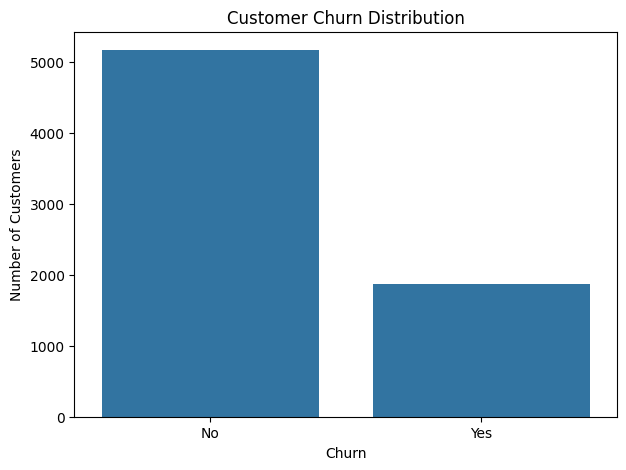

In [233]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Churn')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

#### Numerical Features Analysis

We analyze the numerical features `tenure`, `MonthlyCharges`, and `TotalCharges` to understand their distributions and compare their values between churned and non-churned customers. 

In [234]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

print("=" * 50)
print("NUMERICAL FEATURES SUMMARY")
print("=" * 50)

print(df[numerical_cols].describe().round(2))

NUMERICAL FEATURES SUMMARY
        tenure  MonthlyCharges  TotalCharges
count  7032.00         7032.00       7032.00
mean     32.42           64.80       2283.30
std      24.55           30.09       2266.77
min       1.00           18.25         18.80
25%       9.00           35.59        401.45
50%      29.00           70.35       1397.48
75%      55.00           89.86       3794.74
max      72.00          118.75       8684.80



The dataset contains three main numerical features: `tenure`, `MonthlyCharges`, and `TotalCharges`. After cleaning, all three features contain 7,032 valid observations with no missing values.

`tenure` ranges from 1 to 72 months, while `MonthlyCharges` ranges from 18.25 to 118.75. `TotalCharges` shows a wide range of values, reflecting differences in both customer tenure and monthly charges.

The relatively large variation in `TotalCharges` suggests that customers have substantially different total spending levels. We will next compare these numerical features between churned and non-churned customers to identify potential relationships with churn.

In [235]:
print("=" * 50)
print("AVERAGE VALUES BY CHURN")
print("=" * 50)

print(
    df.groupby('Churn')[numerical_cols]
      .mean()
      .round(2)
)

AVERAGE VALUES BY CHURN
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No      37.65           61.31       2555.34
Yes     17.98           74.44       1531.80



Churned customers also have higher average MonthlyCharges (74.44) than non-churned customers (61.31), indicating a possible relationship between higher monthly charges and churn.

Although churned customers have lower average TotalCharges (1,531.80) than non-churned customers (2,555.34), this should be interpreted carefully because TotalCharges is strongly influenced by tenure. Customers with shorter tenure naturally accumulate lower total charges.

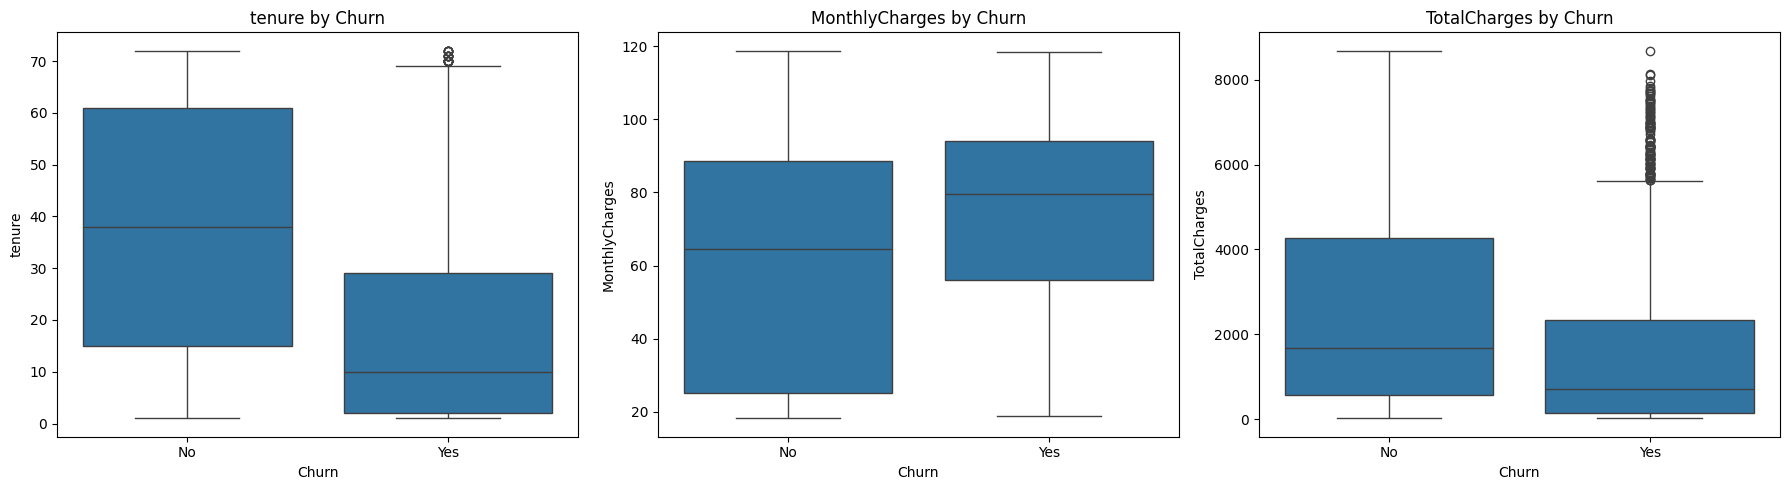

In [236]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(numerical_cols):
    sns.boxplot(
        data=df,
        x='Churn',
        y=col,
        ax=axes[i]
    )
    
    axes[i].set_title(f'{col} by Churn')
    axes[i].set_xlabel('Churn')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

### Categorical Features Analysis

In [237]:
categorical_cols = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]
for col in categorical_cols:
    print(f"\n{'=' * 50}")
    print(f"Churn Rate by {col}")
    print('=' * 50)

    churn_rate = (
        df.groupby(col)['Churn']
          .apply(lambda x: (x == 'Yes').mean() * 100)
          .round(2)
    )

    print(churn_rate)


Churn Rate by gender
gender
Female    26.96
Male      26.20
Name: Churn, dtype: float64

Churn Rate by SeniorCitizen
SeniorCitizen
0    23.65
1    41.68
Name: Churn, dtype: float64

Churn Rate by Partner
Partner
No     32.98
Yes    19.72
Name: Churn, dtype: float64

Churn Rate by Dependents
Dependents
No     31.28
Yes    15.53
Name: Churn, dtype: float64

Churn Rate by PhoneService
PhoneService
No     25.00
Yes    26.75
Name: Churn, dtype: float64

Churn Rate by MultipleLines
MultipleLines
No                  25.08
No phone service    25.00
Yes                 28.65
Name: Churn, dtype: float64

Churn Rate by InternetService
InternetService
DSL            19.00
Fiber optic    41.89
No              7.43
Name: Churn, dtype: float64

Churn Rate by OnlineSecurity
OnlineSecurity
No                     41.78
No internet service     7.43
Yes                    14.64
Name: Churn, dtype: float64

Churn Rate by OnlineBackup
OnlineBackup
No                     39.94
No internet service     7.43
Y

#### Interpretation of Categorical Features vs Churn

The categorical analysis reveals several important differences in churn rates across customer groups. Contract type shows one of the strongest relationships with churn, with month-to-month customers having a much higher churn rate (42.71%) compared with one-year (11.28%) and two-year contracts (2.85%).

Internet service type also shows a strong difference, particularly for Fiber optic customers, who have a churn rate of 41.89%. Payment method is another important factor, with Electronic check customers showing the highest churn rate at 45.29%.

Customers without OnlineSecurity and TechSupport also have substantially higher churn rates than customers who use these services. Senior citizens, customers without partners, and customers without dependents also show higher churn rates.

On the other hand, gender, PhoneService, MultipleLines, StreamingTV, and StreamingMovies show relatively smaller differences in churn rates.

Overall, Contract, InternetService, PaymentMethod, OnlineSecurity, and TechSupport appear to be among the strongest categorical indicators of churn. These relationships will be investigated further through visualization and combined-feature analysis.

In [238]:
def plot_churn_rate(data, column):
    churn_rate = (
        data.groupby(column)['Churn']
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .reset_index(name='ChurnRate')
    )

    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=churn_rate,
        x=column,
        y='ChurnRate'
    )

    plt.title(f'Churn Rate by {column}')
    plt.xlabel(column)
    plt.ylabel('Churn Rate (%)')
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()

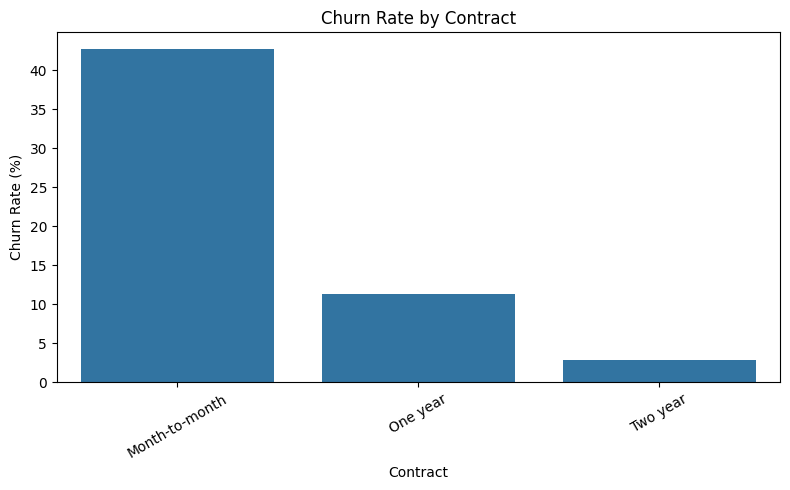

In [239]:
plot_churn_rate(df, 'Contract')

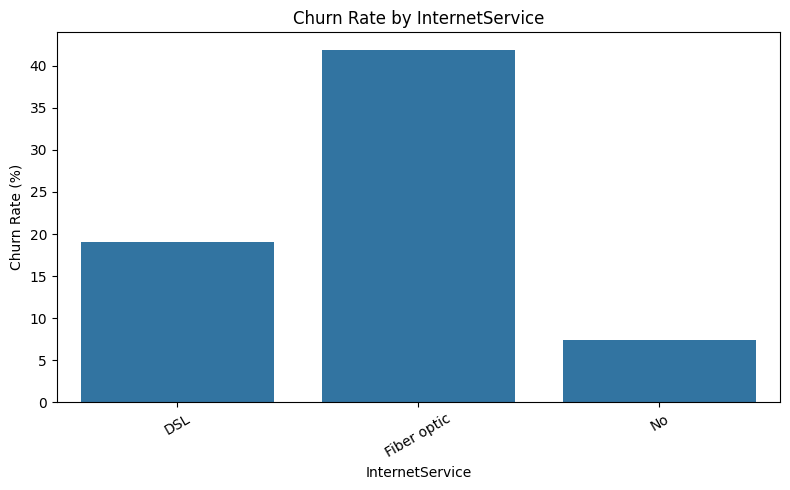

In [240]:
plot_churn_rate(df, 'InternetService')

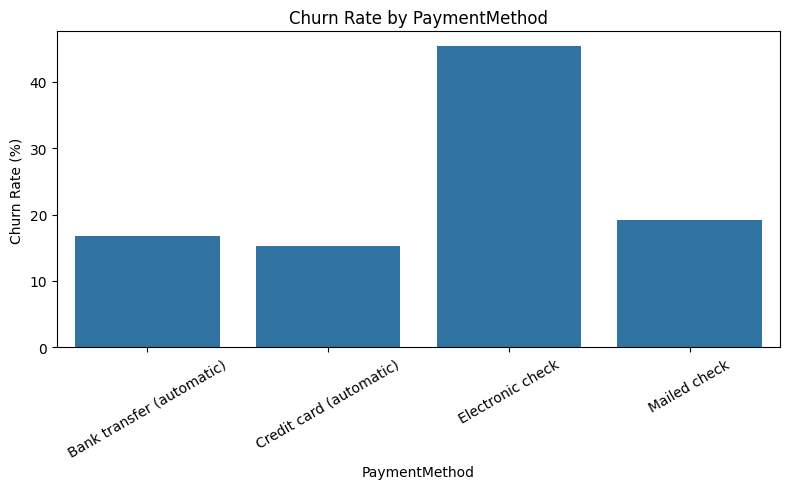

In [241]:
plot_churn_rate(df, 'PaymentMethod')

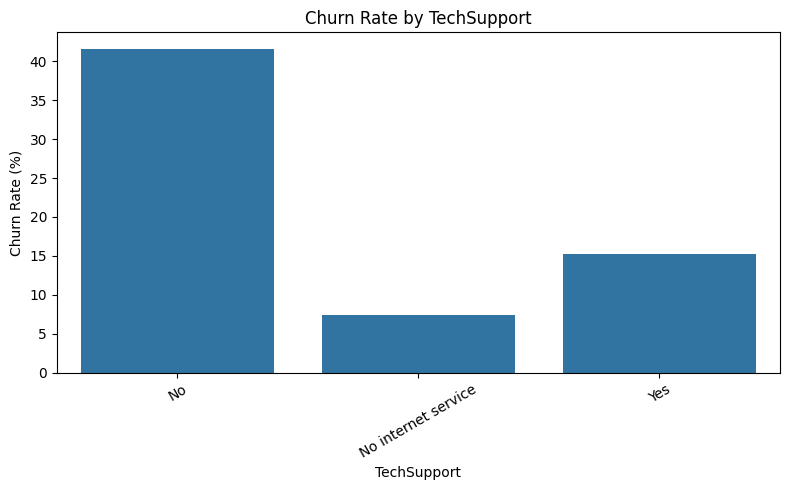

In [242]:
plot_churn_rate(df, 'TechSupport')

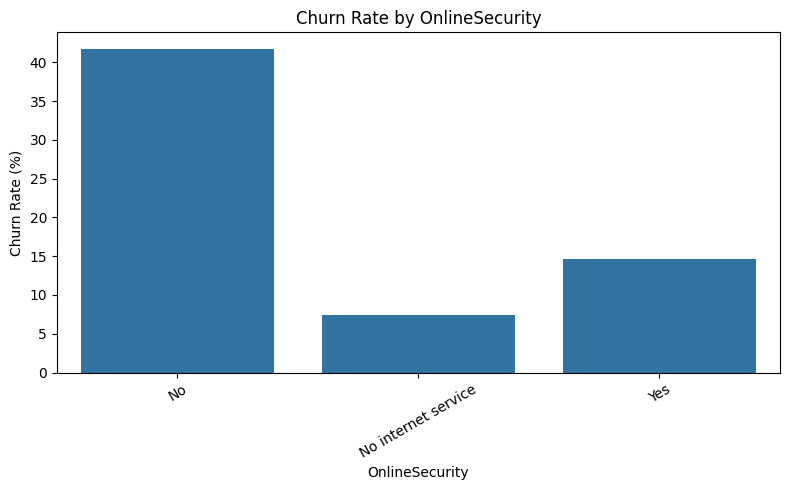

In [243]:
plot_churn_rate(df, 'OnlineSecurity')

### EDA Summary

| Category | Feature | Key Observation | Churn Impact |
|---|---|---|---|
| Numerical | **Tenure** | Churned customers have much lower average tenure | High |
| Numerical | **MonthlyCharges** | Churned customers have higher average monthly charges | High |
| Numerical | **TotalCharges** | Churned customers have lower total charges, mainly due to lower tenure | Moderate |
| Categorical | **Contract** | Month-to-month customers have significantly higher churn | Very High |
| Categorical | **InternetService** | Fiber optic customers have higher churn | High |
| Categorical | **PaymentMethod** | Electronic check customers have higher churn | High |
| Categorical | **TechSupport** | Customers without TechSupport have higher churn | High |
| Categorical | **OnlineSecurity** | Customers without OnlineSecurity have higher churn | High |
| Categorical | **SeniorCitizen** | Senior citizens have higher churn | Moderate |
| Categorical | **PaperlessBilling** | Paperless billing customers have higher churn | Moderate |
| Categorical | **Partner** | Customers without a partner have higher churn | Moderate |
| Categorical | **Dependents** | Customers without dependents have higher churn | Moderate |
| Categorical | **OnlineBackup** | Customers without OnlineBackup have higher churn | Moderate |
| Categorical | **DeviceProtection** | Customers without DeviceProtection have higher churn | Moderate |
| Categorical | **Gender** | Very little difference in churn between genders | Low |
| Categorical | **PhoneService** | Very little difference in churn | Low |
| Categorical | **MultipleLines** | Relatively small difference in churn | Low |
| Categorical | **StreamingTV** | Relatively small difference in churn | Low |
| Categorical | **StreamingMovies** | Relatively small difference in churn | Low |



### Feature Engineering and Encoding

Machine-learning models require numerical input, so categorical features must be converted into numerical representations.

The `customerID` column is removed because it is only an identifier and does not provide meaningful predictive information.

Binary variables such as `Partner`, `Dependents`, `PhoneService`, and `PaperlessBilling` are converted from `Yes/No` into `1/0`. The `gender` and target `Churn` variables are also converted into numerical form.

Service-related features are converted into binary values, where `Yes` is represented by `1` and `No` or unavailable service is represented by `0`.

The `Contract` feature is ordinal encoded because its categories have a natural order based on contract duration: month-to-month, one year, and two year.

`InternetService` and `PaymentMethod` are one-hot encoded because their categories do not represent a numerical scale.

This process converts the dataset into a numerical format suitable for correlation analysis and machine-learning models.

In [244]:

# Keep the original cleaned dataset unchanged
df_model = df.copy()

In [245]:
df_model.head()   

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


We dont need customer id to train our model

In [246]:
df_model = df_model.drop(columns=['customerID'])

In [247]:
import pandas as pd
import numpy as np

# ============================================
# 1. Create a separate dataset for modeling
# ============================================

df_model = df.copy()


# ============================================
# 2. Remove customerID
# ============================================

df_model = df_model.drop(columns=['customerID'])


# ============================================
# 3. Binary columns: Yes/No → 1/0
# ============================================

binary_cols = [
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

for col in binary_cols:
    df_model[col] = df_model[col].map({
        'Yes': 1,
        'No': 0
    })


# ============================================
# 4. Gender: Female/Male → 0/1
# ============================================

df_model['gender'] = df_model['gender'].map({
    'Female': 0,
    'Male': 1
})


# ============================================
# 5. Target variable: Churn → 0/1
# ============================================

df_model['Churn'] = df_model['Churn'].map({
    'No': 0,
    'Yes': 1
})


# ============================================
# 6. Service columns
#    Yes → 1
#    No → 0
#    No service → 0
# ============================================

service_cols = [
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

for col in service_cols:
    df_model[col] = df_model[col].map({
        'Yes': 1,
        'No': 0,
        'No phone service': 0,
        'No internet service': 0
    })


# ============================================
# 7. Contract → Ordinal Encoding
#
# Month-to-month = 0
# One year       = 1
# Two year       = 2
# ============================================

df_model['Contract'] = df_model['Contract'].map({
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
})


# ============================================
# 8. One-Hot Encoding
#    InternetService + PaymentMethod
# ============================================

df_model = pd.get_dummies(
    df_model,
    columns=[
        'InternetService',
        'PaymentMethod'
    ],
    drop_first=True
)


# ============================================
# 9. Convert Boolean columns to integers
# ============================================

bool_cols = df_model.select_dtypes(include='bool').columns

df_model[bool_cols] = df_model[bool_cols].astype(int)


# ============================================
# 10. Final Check
# ============================================

print("=" * 50)
print("ENCODING COMPLETED SUCCESSFULLY")
print("=" * 50)

print("\nShape:")
print(df_model.shape)

print("\nColumn Names:")
print(df_model.columns.tolist())

print("\nData Types:")
print(df_model.dtypes)

print("\nTotal Missing Values:")
print(df_model.isnull().sum().sum())



ENCODING COMPLETED SUCCESSFULLY

Shape:
(7032, 23)

Column Names:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

Data Types:
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
MultipleLines                              int64
OnlineSecurity                             int64
OnlineBackup                               int64
DeviceProtection                           int64

In [248]:
df_model.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,0,1,29.85,29.85,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,...,1,0,56.95,1889.50,0,0,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,...,0,1,53.85,108.15,1,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,...,1,0,42.30,1840.75,0,0,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,0,1,70.70,151.65,1,1,0,0,1,0


#### Encoded Dataset Summary

| Column | Encoding / Type | Values / Meaning |
|---|---|---|
| `gender` | Binary | 0 = Female, 1 = Male |
| `SeniorCitizen` | Binary | 0 = No, 1 = Yes |
| `Partner` | Binary | 0 = No, 1 = Yes |
| `Dependents` | Binary | 0 = No, 1 = Yes |
| `tenure` | Numerical | Customer tenure in months |
| `PhoneService` | Binary | 0 = No, 1 = Yes |
| `MultipleLines` | Binary | 0 = No / No service, 1 = Yes |
| `OnlineSecurity` | Binary | 0 = No / No service, 1 = Yes |
| `OnlineBackup` | Binary | 0 = No / No service, 1 = Yes |
| `DeviceProtection` | Binary | 0 = No / No service, 1 = Yes |
| `TechSupport` | Binary | 0 = No / No service, 1 = Yes |
| `StreamingTV` | Binary | 0 = No / No service, 1 = Yes |
| `StreamingMovies` | Binary | 0 = No / No service, 1 = Yes |
| `Contract` | Ordinal | 0 = Month-to-month, 1 = One year, 2 = Two year |
| `PaperlessBilling` | Binary | 0 = No, 1 = Yes |
| `MonthlyCharges` | Numerical | Monthly customer charges |
| `TotalCharges` | Numerical | Total customer charges |
| `InternetService_No` | One-Hot | 1 = No internet service |
| `InternetService_Fiber optic` | One-Hot | 1 = Fiber optic |
| `PaymentMethod_Credit card (automatic)` | One-Hot | 1 = Credit card automatic |
| `PaymentMethod_Electronic check` | One-Hot | 1 = Electronic check |
| `PaymentMethod_Mailed check` | One-Hot | 1 = Mailed check |
| `Churn` | Target | 0 = No churn, 1 = Churn |



### Correlation Matrix

Correlation Matrix:
                                       gender  SeniorCitizen  Partner  \
gender                                   1.00          -0.00    -0.00   
SeniorCitizen                           -0.00           1.00     0.02   
Partner                                 -0.00           0.02     1.00   
Dependents                               0.01          -0.21     0.45   
tenure                                   0.01           0.02     0.38   
PhoneService                            -0.01           0.01     0.02   
MultipleLines                           -0.01           0.14     0.14   
OnlineSecurity                          -0.02          -0.04     0.14   
OnlineBackup                            -0.01           0.07     0.14   
DeviceProtection                        -0.00           0.06     0.15   
TechSupport                             -0.01          -0.06     0.12   
StreamingTV                             -0.01           0.11     0.12   
StreamingMovies                

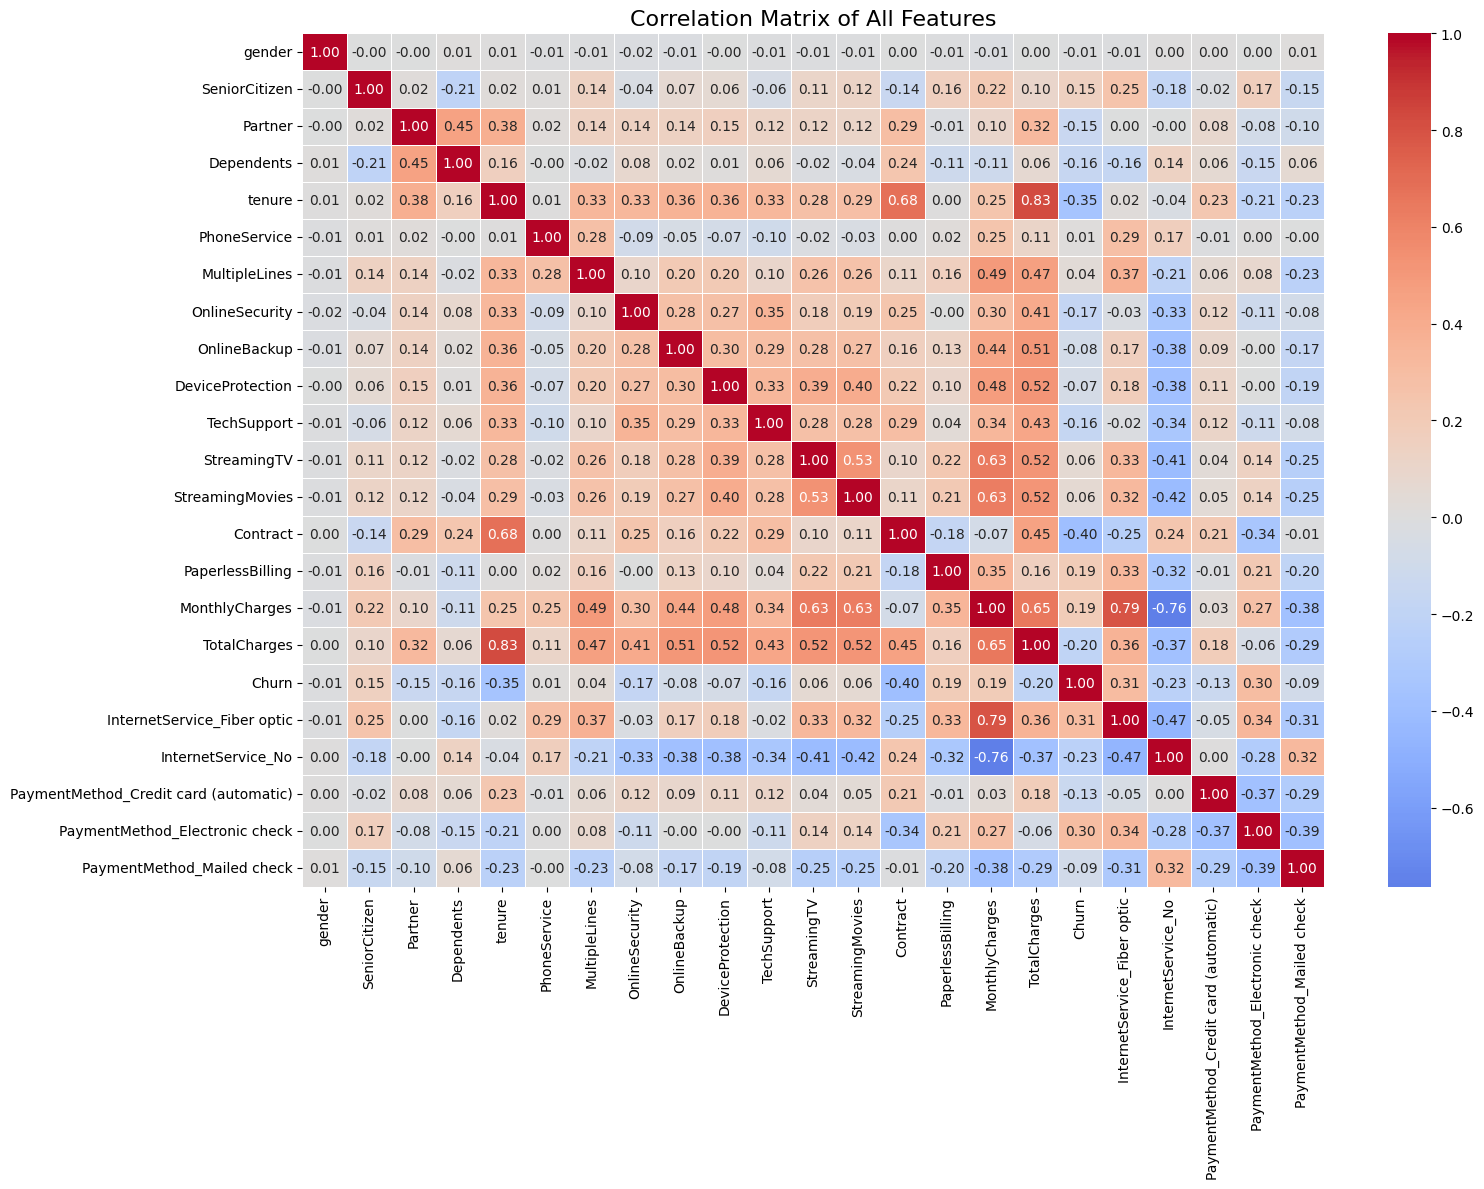

In [249]:
# Calculate correlation matrix
correlation_matrix = df_model.corr()

# Display correlation matrix
print("Correlation Matrix:")
print(correlation_matrix.round(2))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Correlation Matrix of All Features', fontsize=16)
plt.tight_layout()
plt.show()

Correlation with Churn

CORRELATION WITH CHURN
Churn                                    1.000
InternetService_Fiber optic              0.307
PaymentMethod_Electronic check           0.301
MonthlyCharges                           0.193
PaperlessBilling                         0.191
SeniorCitizen                            0.151
StreamingTV                              0.063
StreamingMovies                          0.061
MultipleLines                            0.040
PhoneService                             0.012
gender                                  -0.009
DeviceProtection                        -0.066
OnlineBackup                            -0.082
PaymentMethod_Mailed check              -0.091
PaymentMethod_Credit card (automatic)   -0.135
Partner                                 -0.150
Dependents                              -0.163
TechSupport                             -0.165
OnlineSecurity                          -0.171
TotalCharges                            -0.199
InternetService_No                   

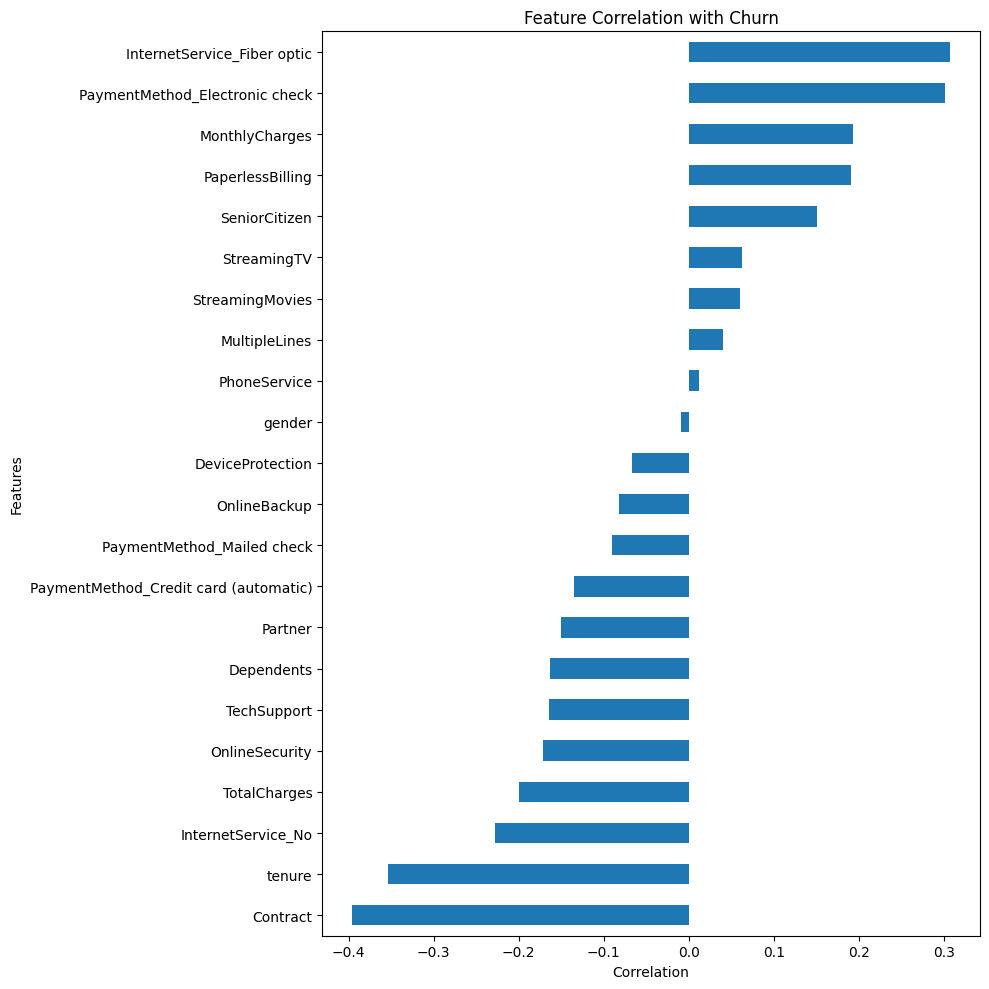

In [250]:
# Correlation of all features with Churn
churn_correlation = (
    df_model.corr()['Churn']
    .sort_values(ascending=False)
)

print("=" * 50)
print("CORRELATION WITH CHURN")
print("=" * 50)

print(churn_correlation.round(3))
plt.figure(figsize=(10, 10))

churn_correlation.drop('Churn').sort_values().plot(
    kind='barh'
)

plt.title('Feature Correlation with Churn')
plt.xlabel('Correlation')
plt.ylabel('Features')

plt.tight_layout()
plt.show()

#### Correlation Analysis Summary

The strongest negative correlations with churn are **Contract (-0.396)** and **tenure (-0.354)**, indicating that longer contracts and longer customer relationships are associated with lower churn.  
**Fiber optic internet (0.307)** and **Electronic check payment (0.301)** show the strongest positive relationships with churn.  
**MonthlyCharges, PaperlessBilling, and SeniorCitizen** also show positive associations, while **OnlineSecurity, TechSupport, Partner, and Dependents** are associated with lower churn.  
Overall, the correlation results support the patterns identified during the EDA.

### Train and Testing Data

In [251]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check shapes
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5625, 22)
X_test : (1407, 22)
y_train: (5625,)
y_test : (1407,)


### Feature Scaling

In [252]:
from sklearn.preprocessing import StandardScaler

# Original continuous numerical features
numerical_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

# Create scaler
scaler = StandardScaler()

# Copy the datasets
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit scaler only on training numerical features
X_train_scaled[numerical_cols] = scaler.fit_transform(
    X_train[numerical_cols]
)

# Apply the same scaler to test numerical features
X_test_scaled[numerical_cols] = scaler.transform(
    X_test[numerical_cols]
)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (5625, 22)
Testing data shape: (1407, 22)


### Model Training

General model training function

In [253]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns


def train_evaluate_model(model, model_name, X_train, X_test, y_train, y_test):

    print("=" * 60)
    print(f"{model_name.upper()}")
    print("=" * 60)

    # -----------------------------
    # 1. Train
    # -----------------------------
    model.fit(X_train, y_train)

    print("\nModel trained successfully.")

    # -----------------------------
    # 2. Predictions
    # -----------------------------
    y_pred = model.predict(X_test)

    # Probability of churn
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # -----------------------------
    # 3. Evaluation Metrics
    # -----------------------------
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    print("\nEvaluation Results:")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    # -----------------------------
    # 4. Classification Report
    # -----------------------------
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # -----------------------------
    # 5. Confusion Matrix
    # -----------------------------
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['No Churn', 'Churn'],
        yticklabels=['No Churn', 'Churn']
    )

    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.tight_layout()
    plt.show()

    # -----------------------------
    # 6. Return everything
    # -----------------------------
    results = {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'confusion_matrix': cm,
        'model': model
    }

    return results

Logistic Regression

LOGISTIC REGRESSION

Model trained successfully.

Evaluation Results:
Accuracy : 0.8031
Precision: 0.6483
Recall   : 0.5668
F1-Score : 0.6049
ROC-AUC  : 0.8362

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



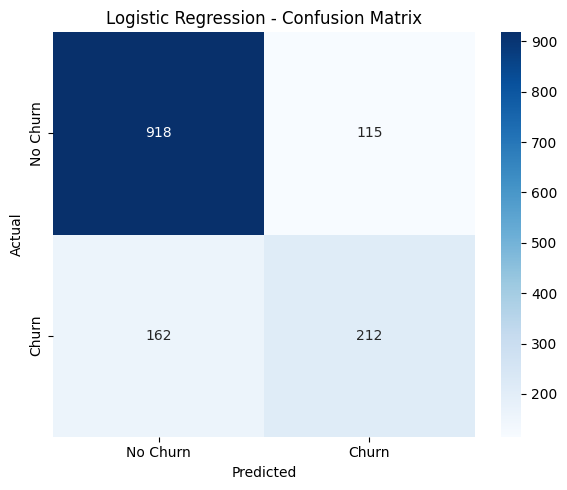

In [254]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_results = train_evaluate_model(
    logistic_model,
    "Logistic Regression",
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

Decision Tree

DECISION TREE

Model trained successfully.

Evaluation Results:
Accuracy : 0.7875
Precision: 0.5954
Recall   : 0.6257
F1-Score : 0.6102
ROC-AUC  : 0.8269

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      1033
           1       0.60      0.63      0.61       374

    accuracy                           0.79      1407
   macro avg       0.73      0.74      0.73      1407
weighted avg       0.79      0.79      0.79      1407



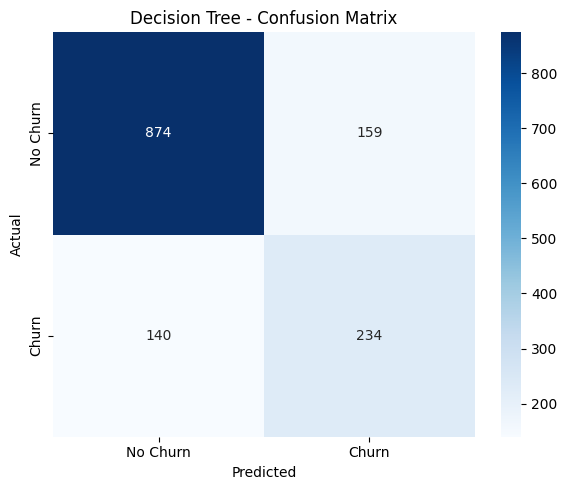

In [255]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_results = train_evaluate_model(
    tree_model,
    "Decision Tree",
    X_train,
    X_test,
    y_train,
    y_test
)

Random Forest

RANDOM FOREST

Model trained successfully.

Evaluation Results:
Accuracy : 0.7932
Precision: 0.6498
Recall   : 0.4813
F1-Score : 0.5530
ROC-AUC  : 0.8401

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.65      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



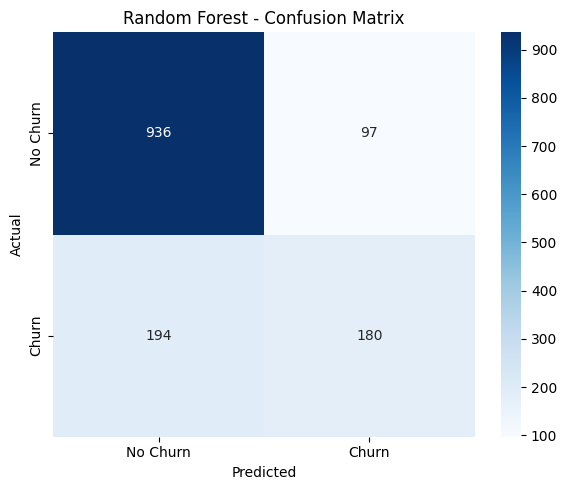

In [256]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

rf_results = train_evaluate_model(
    rf_model,
    "Random Forest",
    X_train,
    X_test,
    y_train,
    y_test
)

Gradient Boosting

GRADIENT BOOSTING

Model trained successfully.

Evaluation Results:
Accuracy : 0.7960
Precision: 0.6390
Recall   : 0.5348
F1-Score : 0.5822
ROC-AUC  : 0.8409

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1033
           1       0.64      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



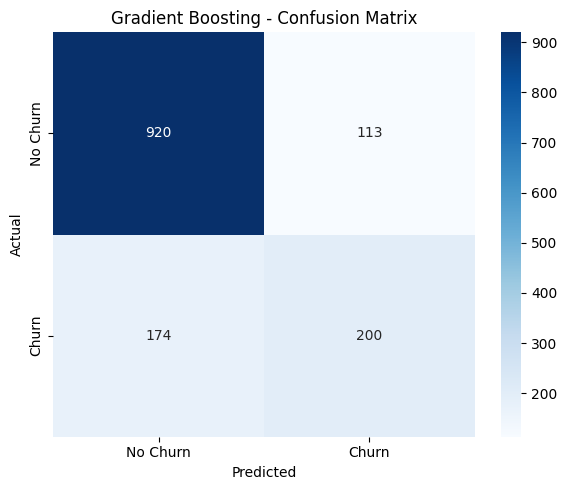

In [257]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_results = train_evaluate_model(
    gb_model,
    "Gradient Boosting",
    X_train,
    X_test,
    y_train,
    y_test
)

In [258]:
comparison = pd.DataFrame([
    {
        'Model': logistic_results['Model'],
        'Accuracy': logistic_results['Accuracy'],
        'Precision': logistic_results['Precision'],
        'Recall': logistic_results['Recall'],
        'F1-Score': logistic_results['F1-Score'],
        'ROC-AUC': logistic_results['ROC-AUC']
    },
    {
        'Model': tree_results['Model'],
        'Accuracy': tree_results['Accuracy'],
        'Precision': tree_results['Precision'],
        'Recall': tree_results['Recall'],
        'F1-Score': tree_results['F1-Score'],
        'ROC-AUC': tree_results['ROC-AUC']
    },
    {
        'Model': rf_results['Model'],
        'Accuracy': rf_results['Accuracy'],
        'Precision': rf_results['Precision'],
        'Recall': rf_results['Recall'],
        'F1-Score': rf_results['F1-Score'],
        'ROC-AUC': rf_results['ROC-AUC']
    },
    {
        'Model': gb_results['Model'],
        'Accuracy': gb_results['Accuracy'],
        'Precision': gb_results['Precision'],
        'Recall': gb_results['Recall'],
        'F1-Score': gb_results['F1-Score'],
        'ROC-AUC': gb_results['ROC-AUC']
    }
])

comparison.sort_values(
    by='Recall',
    ascending=False
).round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Decision Tree,0.7875,0.5954,0.6257,0.6102,0.8269
0,Logistic Regression,0.8031,0.6483,0.5668,0.6049,0.8362
3,Gradient Boosting,0.7960,0.6390,0.5348,0.5822,0.8409
2,Random Forest,0.7932,0.6498,0.4813,0.5530,0.8401


#### Choice of Evaluation Metric
Recall was chosen as the primary evaluation metric because the main goal is to identify as many potential churners as possible. Missing a customer who is likely to churn can result in a lost retention opportunity.

#### Model Selection
Decision Tree was selected because it achieved the highest Recall (62.57%) and F1-Score (61.02%) among the tested models. Since identifying potential churners is important, it provides the most suitable balance for our objective.

#### Tuning Thresholds for Decision Trees

In [259]:
import numpy as np
import pandas as pd

# Get churn probabilities from Decision Tree
y_proba_tree = tree_results['y_pred_proba']

# Thresholds to test
thresholds = np.arange(0.20, 0.71, 0.05)

threshold_results = []

for threshold in thresholds:

    # Convert probability into class prediction
    y_pred_threshold = (y_proba_tree >= threshold).astype(int)

    threshold_results.append({
        'Threshold': threshold,
        'Precision': precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        'Recall': recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        'F1-Score': f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        'Accuracy': accuracy_score(
            y_test,
            y_pred_threshold
        )
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df.round(4))

    Threshold  Precision  Recall  F1-Score  Accuracy
0        0.20     0.4691  0.8529    0.6053    0.7043
1        0.25     0.4950  0.7995    0.6115    0.7299
2        0.30     0.5335  0.7460    0.6221    0.7591
3        0.35     0.5526  0.7166    0.6240    0.7704
4        0.40     0.5679  0.6818    0.6197    0.7775
5        0.45     0.5954  0.6257    0.6102    0.7875
6        0.50     0.5954  0.6257    0.6102    0.7875
7        0.55     0.6078  0.4599    0.5236    0.7775
8        0.60     0.7119  0.2246    0.3415    0.7697
9        0.65     0.7119  0.2246    0.3415    0.7697
10       0.70     0.7119  0.2246    0.3415    0.7697


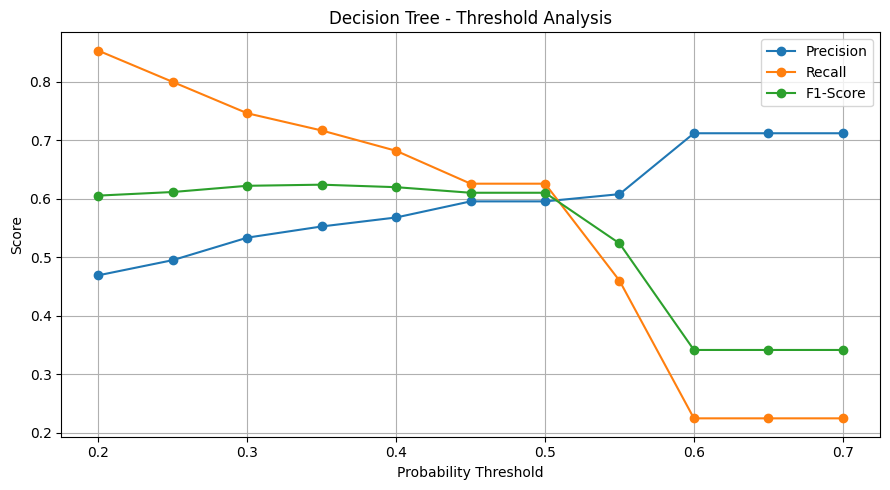

In [260]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    threshold_df['Threshold'],
    threshold_df['Precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    threshold_df['Threshold'],
    threshold_df['Recall'],
    marker='o',
    label='Recall'
)

plt.plot(
    threshold_df['Threshold'],
    threshold_df['F1-Score'],
    marker='o',
    label='F1-Score'
)

plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.title('Decision Tree - Threshold Analysis')

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#### Threshold Selection

A probability threshold of **0.35** was selected because it provides the best balance between Precision and Recall, achieving **71.66% Recall** and the highest **F1-Score (62.40%)**. Lower thresholds increase Recall but produce substantially more false positives.

### Trying SMOTE Technique

In [261]:
from imblearn.over_sampling import SMOTE
print("Class distribution BEFORE SMOTE:")
print(y_train.value_counts())

print("\nClass proportions BEFORE SMOTE:")
print(y_train.value_counts().round(4))

Class distribution BEFORE SMOTE:
Churn
0    4130
1    1495
Name: count, dtype: int64

Class proportions BEFORE SMOTE:
Churn
0    4130
1    1495
Name: count, dtype: int64


In [262]:
# Create SMOTE object
smote = SMOTE(
    random_state=42
)

# Apply SMOTE ONLY to training data
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("SMOTE applied successfully!")

print("\nOriginal training shape:")
print(X_train.shape)

print("\nTraining shape after SMOTE:")
print(X_train_smote.shape)

print("\nClass distribution BEFORE SMOTE:")
print(y_train.value_counts())

print("\nClass distribution AFTER SMOTE:")
print(y_train_smote.value_counts())

SMOTE applied successfully!

Original training shape:
(5625, 22)

Training shape after SMOTE:
(8260, 22)

Class distribution BEFORE SMOTE:
Churn
0    4130
1    1495
Name: count, dtype: int64

Class distribution AFTER SMOTE:
Churn
0    4130
1    4130
Name: count, dtype: int64


DECISION TREE + SMOTE

Model trained successfully.

Evaluation Results:
Accuracy : 0.7235
Precision: 0.4870
Recall   : 0.7513
F1-Score : 0.5910
ROC-AUC  : 0.7945

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.71      0.79      1033
           1       0.49      0.75      0.59       374

    accuracy                           0.72      1407
   macro avg       0.69      0.73      0.69      1407
weighted avg       0.78      0.72      0.74      1407



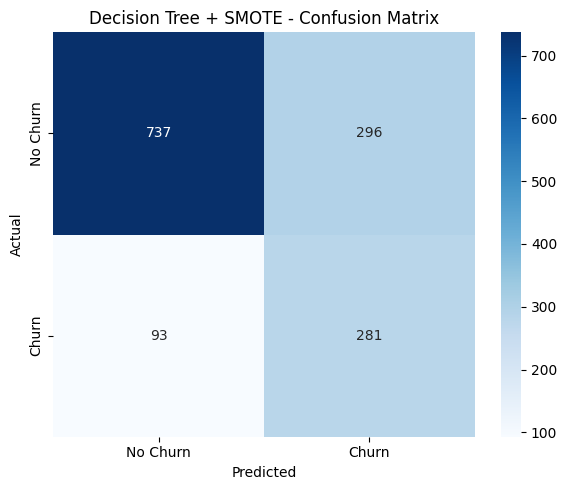

In [263]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree
smote_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

# Train and evaluate
smote_tree_results = train_evaluate_model(
    smote_tree,
    "Decision Tree + SMOTE",
    X_train_smote,
    X_test,
    y_train_smote,
    y_test
)

SMOTE was tested to improve the model's ability to identify churn customers. Although it increased Recall to **75.13%**, it reduced Precision to **48.70%**, F1-Score to **59.10%**, and ROC-AUC to **79.45%**. Therefore, SMOTE did not provide a better overall balance and was not selected for the final model.

### Final Model Decision

The final model is a **Decision Tree without SMOTE**, using a **0.35 probability threshold**. This configuration provides a better balance between Recall and Precision, achieving **71.66% Recall** and the highest **F1-Score of 62.40%** during threshold evaluation. This setup is preferred for identifying potential churners while limiting excessive false positives.

In [264]:
import os
import joblib

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 1. FINAL MODEL CONFIGURATION
# ============================================================

FINAL_THRESHOLD = 0.35

final_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

# ============================================================
# 2. TRAIN FINAL MODEL
# ============================================================

final_model.fit(X_train, y_train)

print("Final Decision Tree trained successfully.")

# ============================================================
# 3. PREDICT CHURN PROBABILITY
# ============================================================

y_test_proba = final_model.predict_proba(X_test)[:, 1]

# ============================================================
# 4. APPLY FINAL THRESHOLD
# ============================================================

y_test_pred = (
    y_test_proba >= FINAL_THRESHOLD
).astype(int)

# ============================================================
# 5. FINAL EVALUATION
# ============================================================

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

# ROC-AUC must use probabilities
roc_auc = roc_auc_score(
    y_test,
    y_test_proba
)

# ============================================================
# 6. DISPLAY FINAL RESULTS
# ============================================================

print("=" * 60)
print("FINAL DECISION TREE MODEL")
print("=" * 60)

print(f"SMOTE     : No")
print(f"Threshold : {FINAL_THRESHOLD}")

print("\nFinal Evaluation Results:")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

# ============================================================
# 7. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["No Churn", "Churn"]
    )
)


Final Decision Tree trained successfully.
FINAL DECISION TREE MODEL
SMOTE     : No
Threshold : 0.35

Final Evaluation Results:
Accuracy  : 0.7704
Precision : 0.5526
Recall    : 0.7166
F1-Score  : 0.6240
ROC-AUC   : 0.8269

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.89      0.79      0.83      1033
       Churn       0.55      0.72      0.62       374

    accuracy                           0.77      1407
   macro avg       0.72      0.75      0.73      1407
weighted avg       0.80      0.77      0.78      1407



In [265]:
# Create model directory
os.makedirs("models", exist_ok=True)

# Save trained model
joblib.dump(
    final_model,
    "models/churn_decision_tree.pkl"
)

# Save threshold
joblib.dump(
    FINAL_THRESHOLD,
    "models/churn_threshold.pkl"
)

# Save feature names
joblib.dump(
    X_train.columns.tolist(),
    "models/model_features.pkl"
)

print("\n" + "=" * 60)
print("FINAL MODEL ARTIFACTS SAVED")
print("=" * 60)

print("Model     : models/churn_decision_tree.pkl")
print("Threshold : models/churn_threshold.pkl")
print("Features  : models/model_features.pkl")


FINAL MODEL ARTIFACTS SAVED
Model     : models/churn_decision_tree.pkl
Threshold : models/churn_threshold.pkl
Features  : models/model_features.pkl


### Final Prediction Function

In [294]:
import pandas as pd
import numpy as np
import joblib


# ============================================================
# 1. LOAD FINAL MODEL ARTIFACTS
# ============================================================

final_model = joblib.load(
    "models/churn_decision_tree.pkl"
)

FINAL_THRESHOLD = joblib.load(
    "models/churn_threshold.pkl"
)

model_features = joblib.load(
    "models/model_features.pkl"
)




# ============================================================
# 2. PREPROCESS CUSTOMER
# ============================================================

def preprocess_customer(customer_df):

    data = customer_df.copy()

    # --------------------------------------------------------
    # Remove ID and target
    # --------------------------------------------------------

    if 'customerID' in data.columns:
        data = data.drop(columns=['customerID'])

    if 'Churn' in data.columns:
        data = data.drop(columns=['Churn'])

    # --------------------------------------------------------
    # Binary columns
    # --------------------------------------------------------

    binary_cols = [
        'Partner',
        'Dependents',
        'PhoneService',
        'PaperlessBilling'
    ]

    for col in binary_cols:
        data[col] = data[col].map({
            'Yes': 1,
            'No': 0
        })

    # --------------------------------------------------------
    # Gender
    # --------------------------------------------------------

    data['gender'] = data['gender'].map({
        'Female': 0,
        'Male': 1
    })

    # --------------------------------------------------------
    # Service columns
    # --------------------------------------------------------

    service_cols = [
        'MultipleLines',
        'OnlineSecurity',
        'OnlineBackup',
        'DeviceProtection',
        'TechSupport',
        'StreamingTV',
        'StreamingMovies'
    ]

    for col in service_cols:

        data[col] = data[col].map({
            'Yes': 1,
            'No': 0,
            'No phone service': 0,
            'No internet service': 0
        })

    # --------------------------------------------------------
    # Contract
    # --------------------------------------------------------

    data['Contract'] = data['Contract'].map({
        'Month-to-month': 0,
        'One year': 1,
        'Two year': 2
    })

    # --------------------------------------------------------
    # Internet Service
    # --------------------------------------------------------

    data['InternetService_Fiber optic'] = (
        data['InternetService'] == 'Fiber optic'
    ).astype(int)

    data['InternetService_No'] = (
        data['InternetService'] == 'No'
    ).astype(int)

    data = data.drop(
        columns=['InternetService']
    )

    # --------------------------------------------------------
    # Payment Method
    # --------------------------------------------------------

    data['PaymentMethod_Credit card (automatic)'] = (
        data['PaymentMethod']
        == 'Credit card (automatic)'
    ).astype(int)

    data['PaymentMethod_Electronic check'] = (
        data['PaymentMethod']
        == 'Electronic check'
    ).astype(int)

    data['PaymentMethod_Mailed check'] = (
        data['PaymentMethod']
        == 'Mailed check'
    ).astype(int)

    data = data.drop(
        columns=['PaymentMethod']
    )

    # --------------------------------------------------------
    # Convert boolean columns
    # --------------------------------------------------------

    bool_cols = data.select_dtypes(
        include='bool'
    ).columns

    data[bool_cols] = data[bool_cols].astype(int)

    # --------------------------------------------------------
    # Add missing model features
    # --------------------------------------------------------

    for feature in model_features:

        if feature not in data.columns:
            data[feature] = 0

    # --------------------------------------------------------
    # Exact feature order
    # --------------------------------------------------------

    data = data[model_features]

    # --------------------------------------------------------
    # Safety check
    # --------------------------------------------------------

    if data.isnull().sum().sum() > 0:

        raise ValueError(
            "Preprocessing produced missing values."
        )

    return data


# ============================================================
# 3. GET TOP FACTORS
# ============================================================

def get_top_factors(customer_processed, customer_original, top_n=3):

    factors = []

    # --------------------------------------------------------
    # Decision Tree feature importance
    # --------------------------------------------------------

    importances = final_model.feature_importances_

    importance_df = pd.DataFrame({
        'feature': model_features,
        'importance': importances
    })

    importance_df = importance_df.sort_values(
        by='importance',
        ascending=False
    )

    # --------------------------------------------------------
    # Check which important features are actually present
    # for this customer
    # --------------------------------------------------------

    for _, row in importance_df.iterrows():

        feature = row['feature']

        # Only consider features that are active
        if feature in customer_processed.columns:

            value = customer_processed.iloc[0][feature]

            if value != 0:

                # Convert encoded feature names
                # back to readable names

                readable_name = feature

                if feature.startswith(
                    'InternetService_'
                ):
                    readable_name = feature.replace(
                        'InternetService_', ''
                    )

                elif feature.startswith(
                    'PaymentMethod_'
                ):
                    readable_name = feature.replace(
                        'PaymentMethod_', ''
                    )

                factors.append(readable_name)

        # Stop once we have enough
        if len(factors) >= top_n:
            break

    # --------------------------------------------------------
    # Fallback if fewer than top_n factors
    # --------------------------------------------------------

    if len(factors) < top_n:

        for _, row in importance_df.iterrows():

            feature = row['feature']

            readable_name = feature

            if feature.startswith(
                'InternetService_'
            ):
                readable_name = feature.replace(
                    'InternetService_', ''
                )

            elif feature.startswith(
                'PaymentMethod_'
            ):
                readable_name = feature.replace(
                    'PaymentMethod_', ''
                )

            if readable_name not in factors:

                factors.append(readable_name)

            if len(factors) >= top_n:
                break

    return factors[:top_n]


# ============================================================
# 4. PREDICT CHURN RISK
# ============================================================

def predict_churn_risk(customer_id):

    # --------------------------------------------------------
    # Find customer
    # --------------------------------------------------------

    customer = df[
        df['customerID'] == customer_id
    ].copy()

    if customer.empty:

        return {
            "error":
            f"Customer ID '{customer_id}' was not found."
        }

    # --------------------------------------------------------
    # Preprocess
    # --------------------------------------------------------

    customer_processed = preprocess_customer(
        customer
    )

    # --------------------------------------------------------
    # Probability
    # --------------------------------------------------------

    risk_score = final_model.predict_proba(
        customer_processed
    )[0][1]

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    prediction_value = int(
        risk_score >= FINAL_THRESHOLD
    )

    if prediction_value == 1:

        prediction = "Likely to Churn"

    else:

        prediction = "Likely to Stay"

    # --------------------------------------------------------
    # Risk Level
    # --------------------------------------------------------

    if risk_score >= 0.70:

        risk_level = "High"

    elif risk_score >= FINAL_THRESHOLD:

        risk_level = "Medium"

    else:

        risk_level = "Low"

    # --------------------------------------------------------
    # Top factors
    # --------------------------------------------------------

    top_factors = get_top_factors(
        customer_processed,
        customer,
        top_n=3
    )

    # --------------------------------------------------------
    # FINAL JSON
    # --------------------------------------------------------

    return {
        "customer_id": customer_id,
        "risk_score": round(
            float(risk_score),
            4
        ),
        "risk_level": risk_level,
        "prediction": prediction,
        "top_factors": top_factors
    }



In [295]:
customer_id = "0376-YMCJC"

result = predict_churn_risk(
    customer_id
)



print(result)

{'customer_id': '0376-YMCJC', 'risk_score': 0.513, 'risk_level': 'Medium', 'prediction': 'Likely to Churn', 'top_factors': ['Fiber optic', 'TotalCharges', 'tenure']}
